In [916]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from warnings import filterwarnings, simplefilter
filterwarnings('ignore')
simplefilter('ignore')
from sklearn.preprocessing import LabelEncoder

In [917]:
# Load the training dataset
df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [918]:
print("Training Data Head (First 5 Rows)")
df.head(5)


Training Data Head (First 5 Rows)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [919]:
print("Training Data Info (Data Types & Missing Values")
df.info()

Training Data Info (Data Types & Missing Values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


# Data Cleaning # 

 # Handle Missing Values # 

In [920]:
# Auto-detect numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Detected Numerical Columns:", num_cols)

# Fill missing numerical values with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after filling numerical columns:")

Detected Numerical Columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Missing values after filling numerical columns:


In [921]:
# Detect categorical columns automatically
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Detected Categorical Columns:", cat_cols)

# Fill missing categorical values with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after filling categorical columns:")
print(df.isnull().sum())

Detected Categorical Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

Missing values after filling categorical columns:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [922]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# duplicate vlaues # 

In [923]:
df.duplicated().sum()

0

In [924]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


# unique values # 

In [925]:
df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [926]:
# Convert to string, strip, title-case
df["Dependents"] = df["Dependents"].astype(str).str.strip().str.title()

# Replace "Nan" or NaN with mode (most frequent value)
df["Dependents"] = df["Dependents"].replace(["Nan", "nan", "NaN"], np.nan)
df["Dependents"].fillna(df["Dependents"].mode()[0], inplace=True)

# Replace 3+ and convert to integer
df["Dependents"] = df["Dependents"].replace({
    "3+": 3,
    "0": 0,
    "1": 1,
    "2": 2
}).astype(int)

print("Dependents cleaned successfully!")


Dependents cleaned successfully!


In [927]:
print(df["Dependents"].dtype)

int32


In [928]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [929]:
# Convert numeric columns safely (in-memory only)
numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount","Loan_Amount_Term"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Numeric columns cleaned successfully!")
print(df[numeric_cols].head())

Numeric columns cleaned successfully!
   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term
0             5849                0.0       128.0             360.0
1             4583             1508.0       128.0             360.0
2             3000                0.0        66.0             360.0
3             2583             2358.0       120.0             360.0
4             6000                0.0       141.0             360.0


In [930]:
df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [931]:
# Fix negative ApplicantIncome
df.loc[df["ApplicantIncome"] < 0, "ApplicantIncome"] = df["ApplicantIncome"].median()

# Fix negative CoapplicantIncome
df.loc[df["CoapplicantIncome"] < 0, "CoapplicantIncome"] = df["CoapplicantIncome"].median()

# Loan amount cannot be 0 or negative
df.loc[df["LoanAmount"] <= 0, "LoanAmount"] = df["LoanAmount"].median()

print("Domain logic errors fixed successfully!")

Domain logic errors fixed successfully!


In [932]:
df.head(4)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y


In [933]:
df = df.drop("Loan_ID", axis=1)

In [934]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y


In [935]:
binary_cols = ["Gender", "Married", "Education", "Self_Employed", "Loan_Status"]

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])


In [936]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,Urban,1
1,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,Rural,0
2,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,Urban,1
3,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,Urban,1
4,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,Urban,1


In [937]:
df = pd.get_dummies(df, columns=["Property_Area"], drop_first=False)

In [938]:
# Convert all new dummy columns from bool → int
property_cols = [col for col in df.columns if col.startswith("Property_Area_")]

for col in property_cols:
    df[col] = df[col].astype(int)

In [939]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,1,0,0,1
1,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,1,0,0
2,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,1,0,0,1
3,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,1,0,0,1
4,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,1,0,0,1


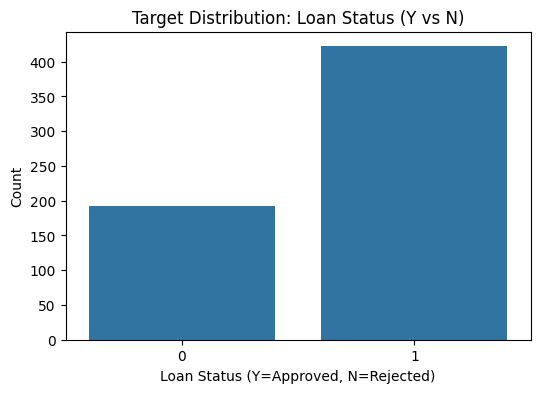

In [940]:
# Check Target Variable Distribution (Loan Status)
plt.figure(figsize=(6, 4))
sns.countplot(x='Loan_Status', data=df)
plt.title('Target Distribution: Loan Status (Y vs N)')
plt.xlabel('Loan Status (Y=Approved, N=Rejected)')
plt.ylabel('Count')
plt.show()

 Loan Status Value Counts 
Loan_Status
1    422
0    192
Name: count, dtype: int64

 Normalized Distribution 
Loan_Status
1    0.687296
0    0.312704
Name: proportion, dtype: float64


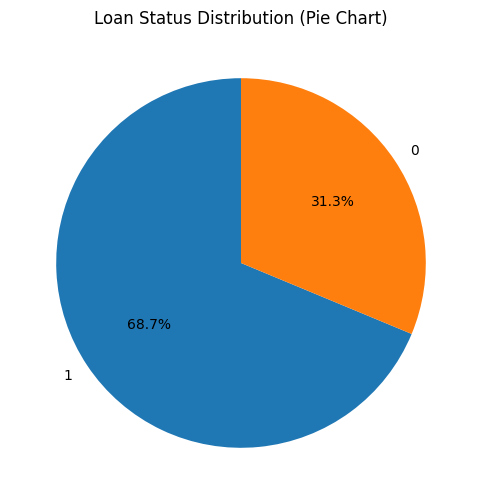

In [941]:
# TARGET VARIABLE DISTRIBUTION

import matplotlib.pyplot as plt
import seaborn as sns

target = "Loan_Status"

# Count values
print(" Loan Status Value Counts ")
print(df[target].value_counts())
print("\n Normalized Distribution ")
print(df[target].value_counts(normalize=True))



#  PIE CHART
plt.figure(figsize=(6,6))
df[target].value_counts().plot(
    kind="pie", autopct="%1.1f%%", startangle=90
)
plt.title("Loan Status Distribution (Pie Chart)")
plt.ylabel("")
plt.show()


In [942]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,1,0,0,1
1,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,1,0,0
2,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,1,0,0,1
3,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,1,0,0,1
4,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,1,0,0,1


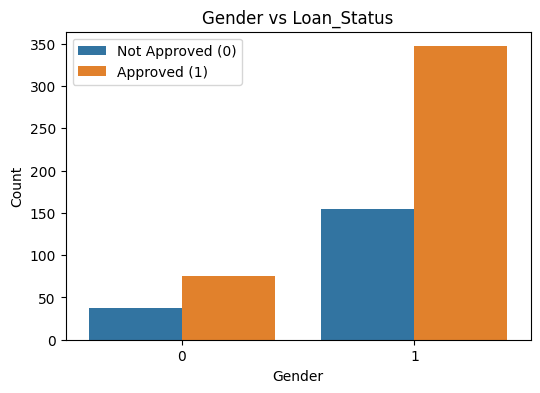

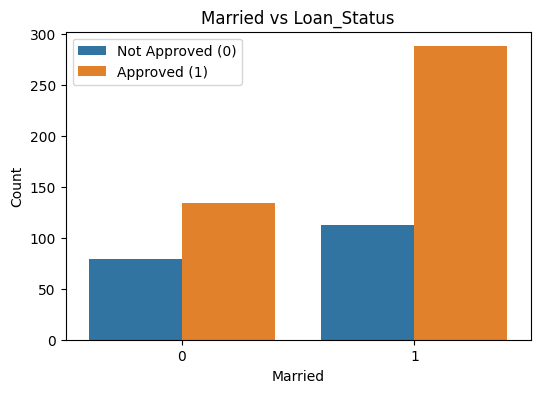

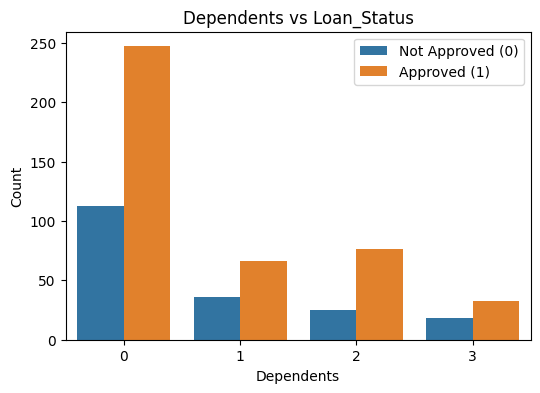

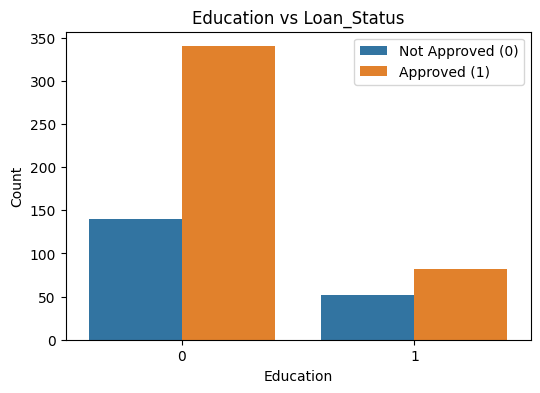

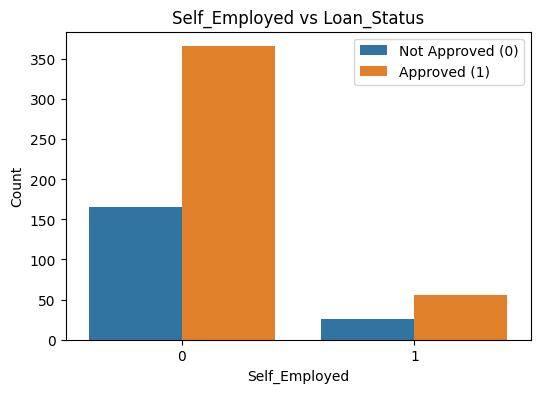

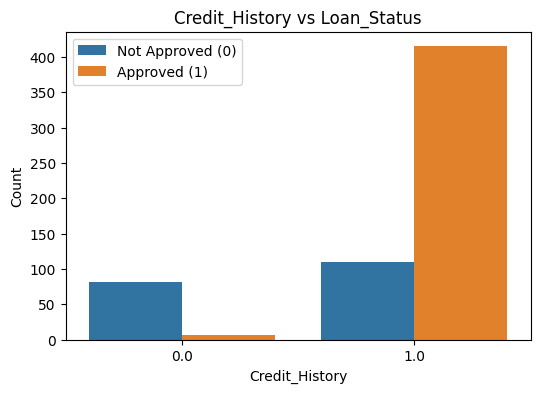

In [943]:
# CATEGORICAL BINARY FEATURES 
cat_features = ["Gender", "Married", "Dependents", "Education", "Self_Employed","Credit_History"]

for col in cat_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col], hue=df["Loan_Status"])
    plt.title(f"{col} vs Loan_Status")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(["Not Approved (0)", "Approved (1)"])
    plt.show()

In [944]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,1,0,0,1
1,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,1,0,0
2,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,1,0,0,1
3,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,1,0,0,1
4,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,1,0,0,1


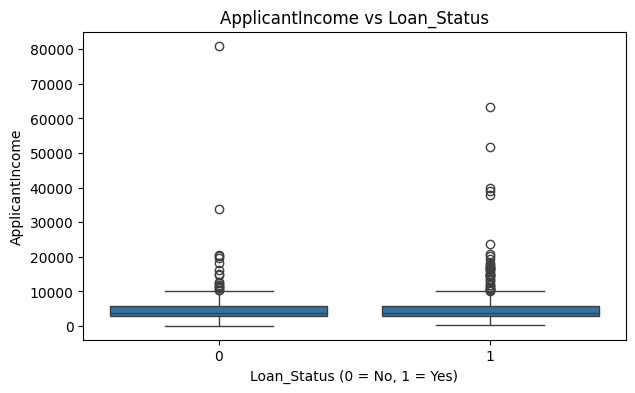

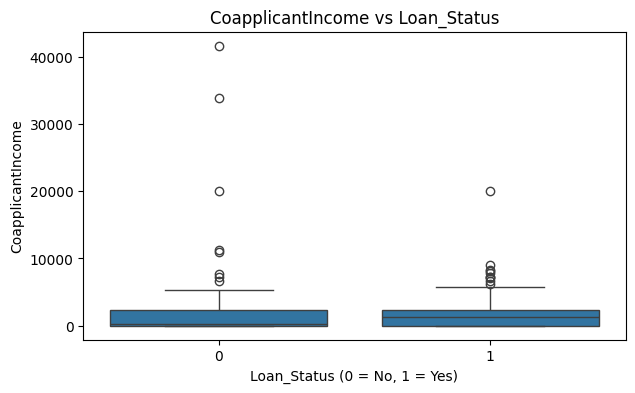

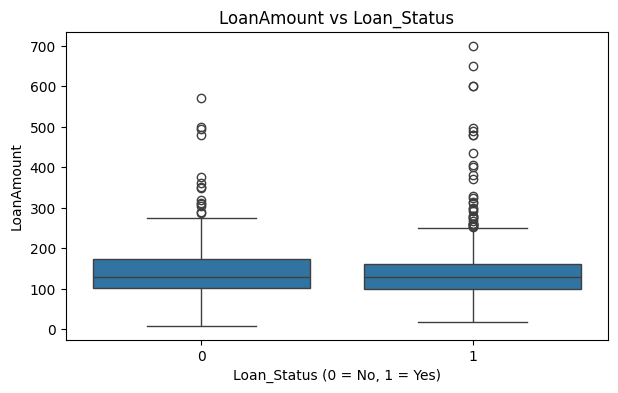

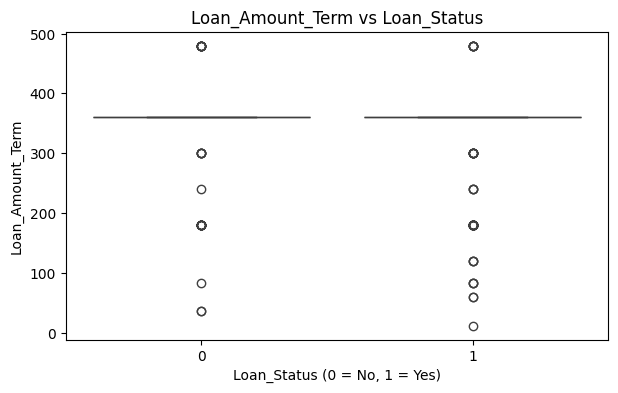

In [945]:
# NUMERIC FEATURES 
num_features = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount","Loan_Amount_Term"]

for col in num_features:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df["Loan_Status"], y=df[col])
    plt.title(f"{col} vs Loan_Status")
    plt.xlabel("Loan_Status (0 = No, 1 = Yes)")
    plt.ylabel(col)
    plt.show()

In [946]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,1,0,0,1
1,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,1,0,0
2,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,1,0,0,1
3,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,1,0,0,1
4,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,1,0,0,1


In [947]:
df['Loan_Amount_Term'].unique()

array([360., 120., 240., 180.,  60., 300., 480.,  36.,  84.,  12.])

In [948]:
df['Credit_History'].unique()

array([1., 0.])

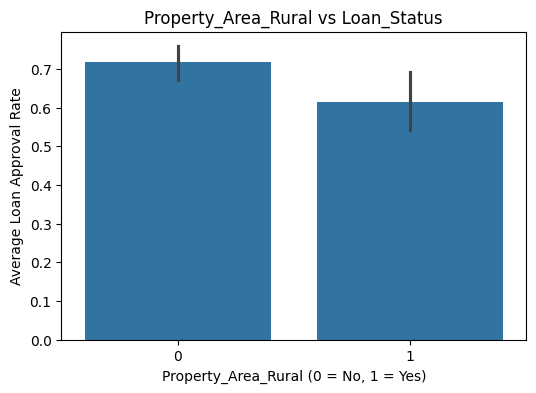

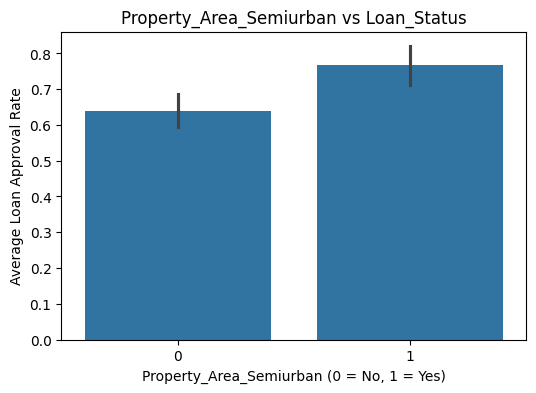

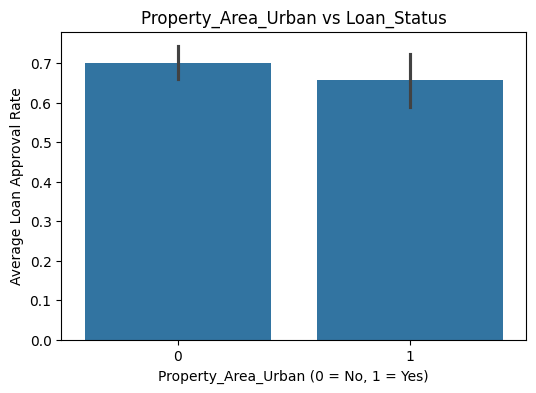

In [949]:
# PROPERTY AREA (ONE-HOT ENCODED) 
area_features = ["Property_Area_Rural", "Property_Area_Semiurban", "Property_Area_Urban"]

for col in area_features:
    plt.figure(figsize=(6,4))
    sns.barplot(x=df[col], y=df["Loan_Status"])
    plt.title(f"{col} vs Loan_Status")
    plt.xlabel(f"{col} (0 = No, 1 = Yes)")
    plt.ylabel("Average Loan Approval Rate")
    plt.show()

# Handling outliers # 

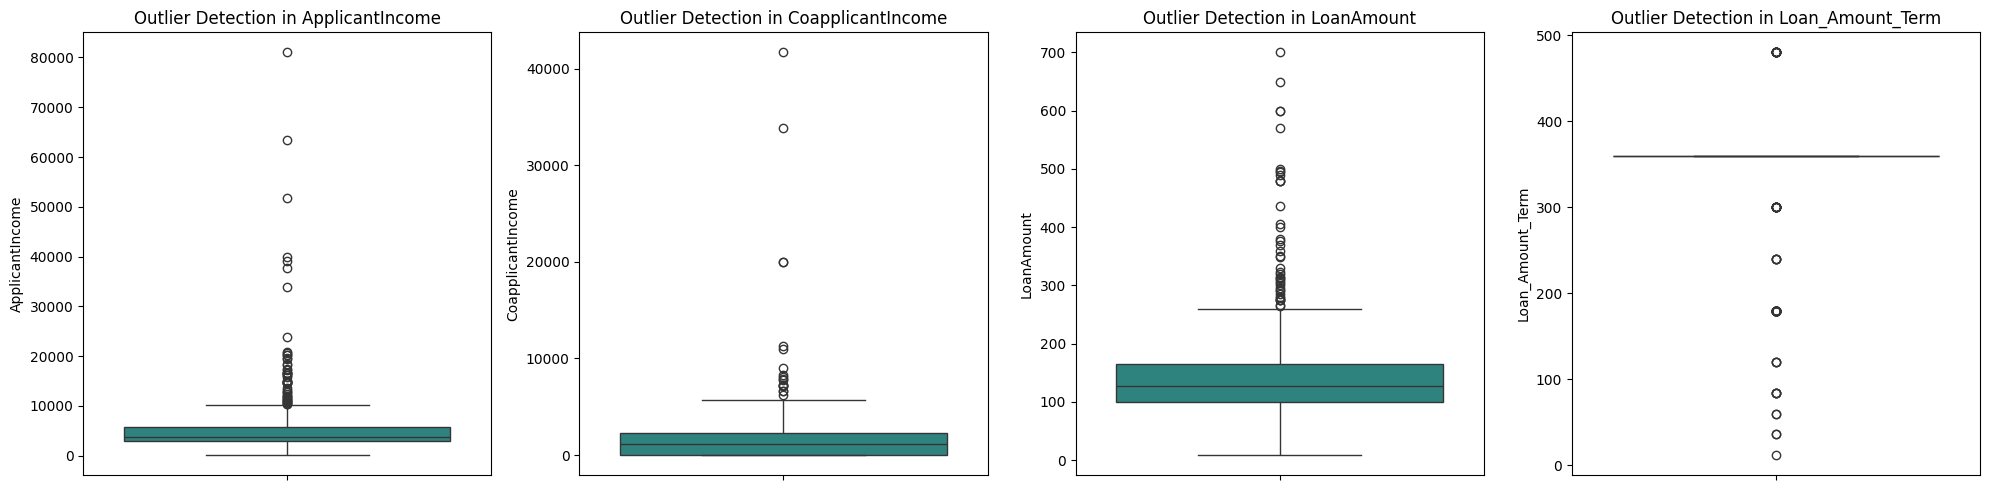

In [950]:
# Define the numerical features where outliers are most likely to occur
numerical_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount','Loan_Amount_Term']

# Code for Outlier Visualization using Seaborn Box Plots
plt.figure(figsize=(20, 5))

for i, feature in enumerate(numerical_features):
    # Create a subplot for each feature
    plt.subplot(1, 4, i + 1)
    
    # Generate the box plot
    sns.boxplot(y=df[feature], palette='viridis')
    
    plt.title(f'Outlier Detection in {feature}')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

In [951]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

In [952]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[column] = df[column].clip(lower, upper)
    return df

# Apply to all numeric columns
for col in num_cols:
    df = cap_outliers_iqr(df, col)

In [953]:
for col in num_cols:
    df = cap_outliers_iqr(df, col)

# outlier confirmation # 

In [954]:
def count_remaining_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)][column].count()

    print(f"{column}: Remaining Outliers = {outliers}")

for col in num_cols:
    count_remaining_outliers(df, col)

ApplicantIncome: Remaining Outliers = 0
CoapplicantIncome: Remaining Outliers = 0
LoanAmount: Remaining Outliers = 0


In [955]:
df.dtypes

Gender                       int32
Married                      int32
Dependents                   int32
Education                    int32
Self_Employed                int32
ApplicantIncome            float64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Loan_Status                  int32
Property_Area_Rural          int32
Property_Area_Semiurban      int32
Property_Area_Urban          int32
dtype: object

In [956]:
df.head(6)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,1,0,0,1
1,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,1,0,0
2,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,1,0,0,1
3,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,1,0,0,1
4,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,1,0,0,1
5,1,1,2,0,1,5417.0,4196.0,261.5,360.0,1.0,1,0,0,1


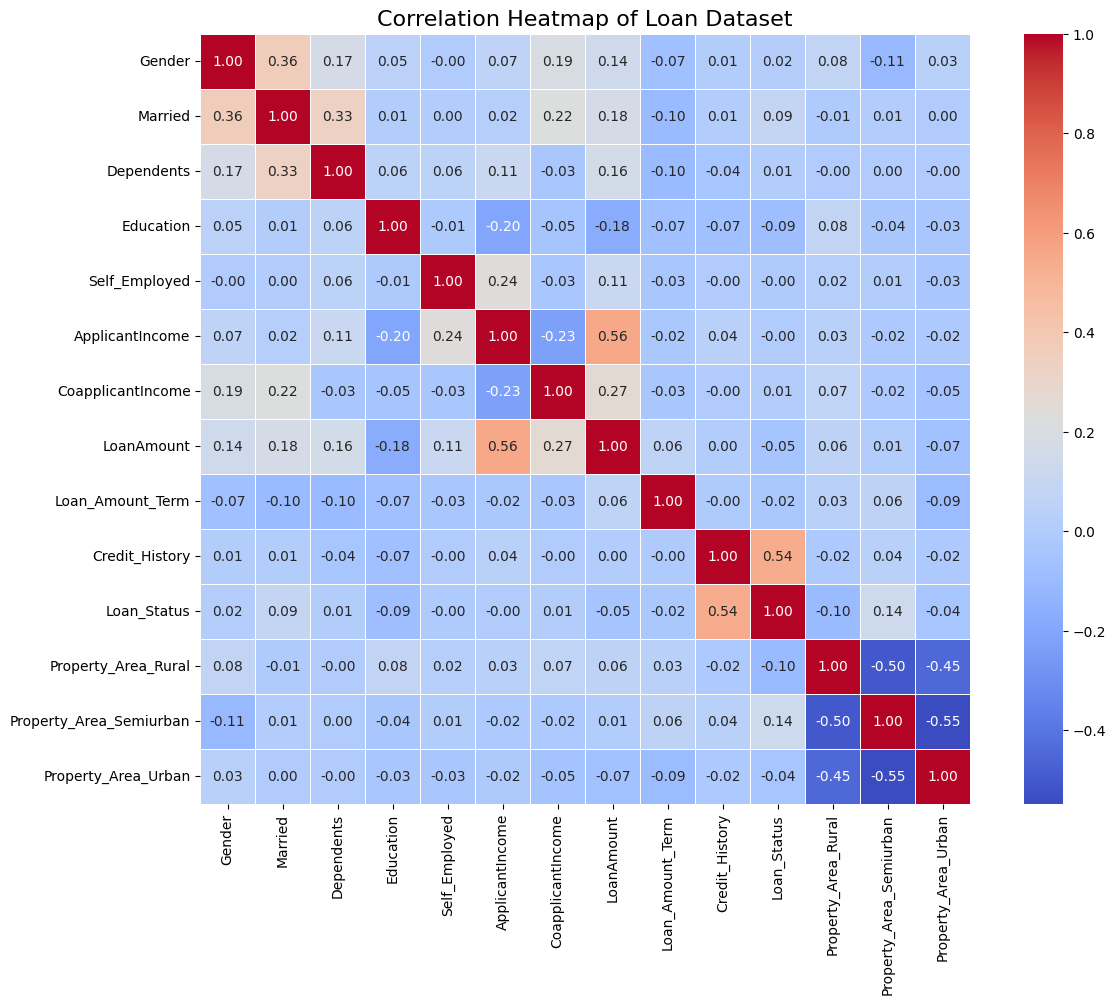

In [957]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr = df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,          # show correlation values
    cmap='coolwarm',     # color style
    linewidths=0.5,
    fmt=".2f",           # two decimal places
    square=True
)

plt.title("Correlation Heatmap of Loan Dataset", fontsize=16)
plt.show()

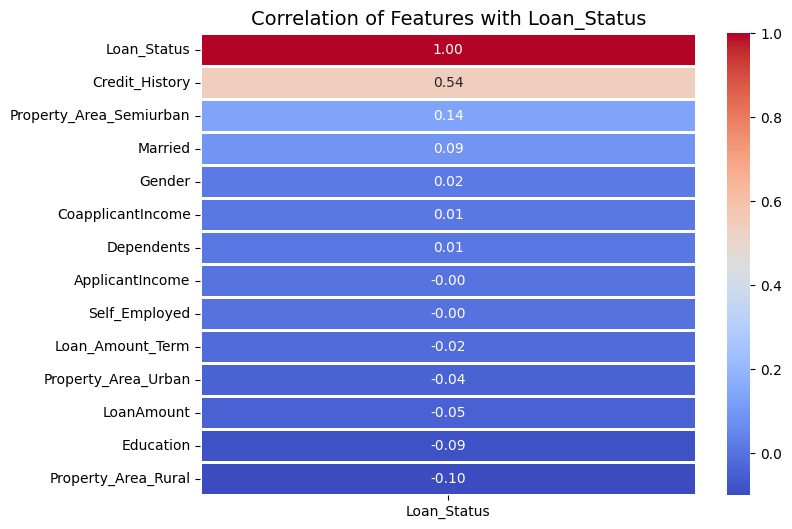

In [958]:
plt.figure(figsize=(8, 6))

# Sort by strongest correlation with Loan_Status
loan_corr = corr['Loan_Status'].sort_values(ascending=False)

sns.heatmap(
    loan_corr.to_frame(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=1
)

plt.title("Correlation of Features with Loan_Status", fontsize=14)
plt.show()


In [959]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,1,0,0,1
1,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,1,0,0
2,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,1,0,0,1
3,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,1,0,0,1
4,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,1,0,0,1


In [960]:
import pandas as pd

# Compute correlations with Loan_Status
corr_table = df.corr()['Loan_Status'].sort_values(ascending=False)

# Convert to dataframe for better display
corr_df = corr_table.to_frame().reset_index()
corr_df.columns = ["Feature", "Correlation_with_Loan_Status"]

print(corr_df)

                    Feature  Correlation_with_Loan_Status
0               Loan_Status                      1.000000
1            Credit_History                      0.540556
2   Property_Area_Semiurban                      0.136540
3                   Married                      0.091478
4                    Gender                      0.017987
5         CoapplicantIncome                      0.011983
6                Dependents                      0.010118
7           ApplicantIncome                     -0.000442
8             Self_Employed                     -0.003700
9          Loan_Amount_Term                     -0.022549
10      Property_Area_Urban                     -0.043621
11               LoanAmount                     -0.047262
12                Education                     -0.085884
13      Property_Area_Rural                     -0.100694


In [961]:
from sklearn.preprocessing import StandardScaler

scale_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [962]:
df.head(59)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,0.497164,-0.874587,-0.168041,360.0,1.0,1,0,0,1
1,1,1,1,0,0,-0.013767,0.054395,-0.168041,360.0,1.0,0,1,0,0
2,1,1,0,0,1,-0.652632,-0.874587,-1.280462,360.0,1.0,1,0,0,1
3,1,1,0,1,0,-0.820924,0.578025,-0.311579,360.0,1.0,1,0,0,1
4,1,0,0,0,0,0.558104,-0.874587,0.065209,360.0,1.0,1,0,0,1
5,1,1,2,0,1,0.322818,1.710299,2.227252,360.0,1.0,1,0,0,1
6,1,1,0,1,0,-0.921819,0.059323,-0.760136,360.0,1.0,1,0,0,1
7,1,1,3,0,0,-0.638103,0.667966,0.370227,360.0,0.0,0,0,1,0
8,1,1,2,0,0,-0.246632,0.065483,0.549650,360.0,1.0,1,0,0,1
9,1,1,1,0,0,2.241532,2.663383,2.227252,360.0,1.0,0,0,1,0


# Logistic Regression Model #

In [963]:
#  Separate Features & Target
X = df.drop("Loan_Status", axis=1)   # All input features
y = df["Loan_Status"]                # Target variable

In [964]:
#  Train–Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [965]:
# Logistic Regression Grid Search

param_grid = {
    "penalty": ["l2"],                   # only L2 allowed for lbfgs
    "C": [0.01, 0.1, 1, 5, 10, 50, 100],  # model complexity
    "solver": ["lbfgs", "liblinear"],    # good solvers
    "max_iter": [200, 400, 800, 1200],   # to reduce underfitting
}

log_reg = LogisticRegression()

grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,                     # 5-Fold cross validation
    scoring="accuracy",
    n_jobs=-1,                # use all CPU cores
    verbose=1
)

grid.fit(X_train, y_train)


# Print best parameters + CV score

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

# Train final model using best params

best_model = grid.best_estimator_

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("\nFinal Model Performance:")
print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

# Underfitting / Overfitting Check

if train_acc < 0.80:
    print("\n Model is still UNDERFITTING — need more complexity or more features.")
elif train_acc - test_acc > 0.10:
    print("\n Model is OVERFITTING — need regularization or less complexity.")
else:
    print("\n Model is well-balanced.")


Fitting 5 folds for each of 56 candidates, totalling 280 fits
Best Parameters: {'C': 10, 'max_iter': 200, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Accuracy: 0.8003916718202433

Final Model Performance:
Training Accuracy: 0.7983706720977597
Testing Accuracy : 0.8536585365853658

 Model is still UNDERFITTING — need more complexity or more features.


# KNN #

In [966]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Pipeline for KNN + Scaling

pipe = Pipeline([
    ("scaler", StandardScaler()),     # KNN needs scaling
    ("knn", KNeighborsClassifier())
])

# Hyperparameter Grid for KNN

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan", "minkowski"],
    "knn__p": [1, 2]     # p=1 → Manhattan, p=2 → Euclidean
}


# Grid Search CV

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)


# Final Model Evaluation

best_knn = grid.best_estimator_

train_pred = best_knn.predict(X_train)
test_pred = best_knn.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("\nFinal Model Performance:")
print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

# Underfitting / Overfitting Check

if train_acc < 0.80:
    print("\n Model is UNDERFITTING — increase neighbors or tune features.")
elif train_acc - test_acc > 0.10:
    print("\n Model is OVERFITTING — reduce neighbors or change weights.")
else:
    print("\n Model is well-balanced.")


Fitting 5 folds for each of 84 candidates, totalling 420 fits

Best Parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'uniform'}
Best CV Accuracy: 0.7760049474335189

Final Model Performance:
Training Accuracy: 0.7881873727087576
Testing Accuracy : 0.8211382113821138

 Model is UNDERFITTING — increase neighbors or tune features.


In [967]:
# Feature Engineering to Reduce Underfitting
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
df["EMI"] = df["LoanAmount"] / df["Loan_Amount_Term"]
df["BalanceIncome"] = df["TotalIncome"] - (df["EMI"] * 1000)

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
    "knn__p": [1, 2]
}

grid = GridSearchCV(
    pipe, param_grid, cv=5, scoring="accuracy",
    verbose=1, n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

best_knn = grid.best_estimator_

train_acc = accuracy_score(y_train, best_knn.predict(X_train))
test_acc = accuracy_score(y_test, best_knn.predict(X_test))

print("\nTraining Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 5, 'knn__p': 1, 'knn__weights': 'uniform'}
Best CV Accuracy: 0.7860441146155431

Training Accuracy: 0.8431771894093686
Testing Accuracy : 0.7804878048780488


# Decision Tree Classifier #

In [968]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# Split Data

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree Model

dt = DecisionTreeClassifier(random_state=42)


# Hyperparameter Tuning

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 3, 5, 7, 10, 12, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": [None, "sqrt", "log2"]
}

grid = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)


# Evaluate Best Model

best_dt = grid.best_estimator_

train_pred = best_dt.predict(X_train)
test_pred = best_dt.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("\nModel Performance:")
print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)


# Underfitting / Overfitting Detection

if train_acc < 0.80:
    print("\n Model is UNDERFITTING — allow deeper tree or reduce regularization.")
elif train_acc - test_acc > 0.10:
    print("\n Model is OVERFITTING — reduce max_depth or increase min_samples_leaf.")
else:
    print("\n Model is well-balanced (No underfitting/overfitting).")


Fitting 5 folds for each of 840 candidates, totalling 4200 fits

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 2}
Best CV Accuracy: 0.8186559472273757

Model Performance:
Training Accuracy: 0.8228105906313645
Testing Accuracy : 0.7560975609756098

 Model is well-balanced (No underfitting/overfitting).


# Bayesian Belief (Gaussian Naive Bayes) #

In [969]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# 2. Parameter Grid for GaussianNB

param_grid = {
    "var_smoothing": np.logspace(-12, -6, 30)   # 30 values between 1e-12 and 1e-6
}

# 3. Grid Search

grid = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)


# 4. Train the Best Model

best_nb = grid.best_estimator_


# 5. Predictions

y_pred_train = best_nb.predict(X_train)
y_pred_test = best_nb.predict(X_test)


# 6. Evaluation

print("\nTraining Accuracy :", accuracy_score(y_train, y_pred_train))
print("Testing Accuracy  :", accuracy_score(y_test, y_pred_test))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


Best Parameters: {'var_smoothing': 8.531678524172815e-09}
Best CV Accuracy: 0.8064522778808494

Training Accuracy : 0.8167006109979633
Testing Accuracy  : 0.7886178861788617

Confusion Matrix:
[[18 25]
 [ 1 79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [970]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status',
       'Property_Area_Rural', 'Property_Area_Semiurban', 'Property_Area_Urban',
       'TotalIncome', 'EMI', 'BalanceIncome'],
      dtype='object')

# Prediction Function #

In [972]:
import numpy as np
import pandas as pd

# -------------------------------------------------------
# 1. PREDICTION FUNCTION
# -------------------------------------------------------

def predict_loan_status(model, Gender, Married, Dependents, Education, Self_Employed,
                        ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term,
                        Credit_History, Property_Area):

    # ---- Step 1: Create DataFrame ----
    input_data = pd.DataFrame({
        "Gender": [Gender],
        "Married": [Married],
        "Dependents": [Dependents],
        "Education": [Education],
        "Self_Employed": [Self_Employed],
        "ApplicantIncome": [ApplicantIncome],
        "CoapplicantIncome": [CoapplicantIncome],
        "LoanAmount": [LoanAmount],
        "Loan_Amount_Term": [Loan_Amount_Term],
        "Credit_History": [Credit_History],
        "Property_Area": [Property_Area]
    })

    # ---- Step 2: One-Hot Encode Property_Area ----
    areas = ["Rural", "Semiurban", "Urban"]

    for area in areas:
        input_data[f"Property_Area_{area}"] = 1 if Property_Area == area else 0

    input_data.drop("Property_Area", axis=1, inplace=True)

    # ---- Step 3: Feature Engineering ----
    input_data["TotalIncome"] = input_data["ApplicantIncome"] + input_data["CoapplicantIncome"]
    input_data["EMI"] = input_data["LoanAmount"] / input_data["Loan_Amount_Term"]
    input_data["BalanceIncome"] = input_data["TotalIncome"] - input_data["EMI"]

    # ---- Step 4: Ensure correct column order ----
    final_cols = [
        'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
        'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
        'Loan_Amount_Term', 'Credit_History',
        'Property_Area_Rural', 'Property_Area_Semiurban', 'Property_Area_Urban',
        'TotalIncome', 'EMI', 'BalanceIncome'
    ]

    input_data = input_data[final_cols]

    # ---- Step 5: Predict ----
    prediction = model.predict(input_data)[0]

    return "Approved" if prediction == 1 else "Rejected"


In [973]:
result = predict_loan_status(
    model = best_dt,      # your trained decision tree model
    Gender = 1,
    Married = 1,
    Dependents = 2,
    Education = 0,
    Self_Employed = 0,
    ApplicantIncome = 5000,
    CoapplicantIncome = 1500,
    LoanAmount = 150,
    Loan_Amount_Term = 360,
    Credit_History = 1,
    Property_Area = "Urban"
)

print("Prediction:", result)

Prediction: Approved


In [975]:
import pickle

#  Save Decision Tree Model

with open("decision_tree_model.pkl", "wb") as file:
    pickle.dump(best_dt, file)     # best_dt is your trained Decision Tree model

print("✔ decision_tree_model.pkl saved")



#  Save Column Names (important)

model_columns = X_train.columns.tolist()   # capture column order

with open("model_columns.pkl", "wb") as file:
    pickle.dump(model_columns, file)

print("✔ model_columns.pkl saved")



# Save Label Encoders (ONLY if you used them)

# Example: you had label encoders for Gender, Married, etc.

try:
    with open("label_encoders.pkl", "wb") as file:
        pickle.dump(label_encoders, file)   # dictionary of your encoders
    print("label_encoders.pkl saved")
except:
    print("No label_encoders variable found — skipped")


✔ decision_tree_model.pkl saved
✔ model_columns.pkl saved
No label_encoders variable found — skipped


In [976]:
import numpy as np
import pandas as pd
import pickle

# ------------------------------------------------------
# Load Saved Model and Columns
# ------------------------------------------------------
model = pickle.load(open("decision_tree_model.pkl", "rb"))
model_columns = pickle.load(open("model_columns.pkl", "rb"))

# Load encoders if you used them
try:
    label_encoders = pickle.load(open("label_encoders.pkl", "rb"))
except:
    label_encoders = None   # not required if your data is already encoded


# ------------------------------------------------------
# Prediction Function
# ------------------------------------------------------
def predict_loan_status(input_data: dict):

    # Convert input dictionary → DataFrame
    df = pd.DataFrame([input_data])

    # -----------------------------
    # Apply label encoders (if used)
    # -----------------------------
    if label_encoders is not None:
        for col, encoder in label_encoders.items():
            if col in df.columns:
                df[col] = encoder.transform(df[col])

    # -----------------------------
    # Add missing columns (if any)
    # -----------------------------
    for col in model_columns:
        if col not in df.columns:
            df[col] = 0   # default value

    # -----------------------------
    # Arrange column order
    # -----------------------------
    df = df[model_columns]

    # -----------------------------
    # Predict
    # -----------------------------
    prediction = model.predict(df)[0]

    return "Approved" if prediction == 1 else "Rejected"


In [977]:
sample_input = {
    "Gender": 1,
    "Married": 1,
    "Dependents": 0,
    "Education": 0,
    "Self_Employed": 0,
    "ApplicantIncome": 0.52,
    "CoapplicantIncome": -0.65,
    "LoanAmount": -0.12,
    "Loan_Amount_Term": 360.0,
    "Credit_History": 1.0,
    "Property_Area_Rural": 0,
    "Property_Area_Semiurban": 1,
    "Property_Area_Urban": 0,
    "TotalIncome": 1330,
    "EMI": 50,
    "BalanceIncome": 700
}

print(predict_loan_status(sample_input))


Approved
